![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [6]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [7]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

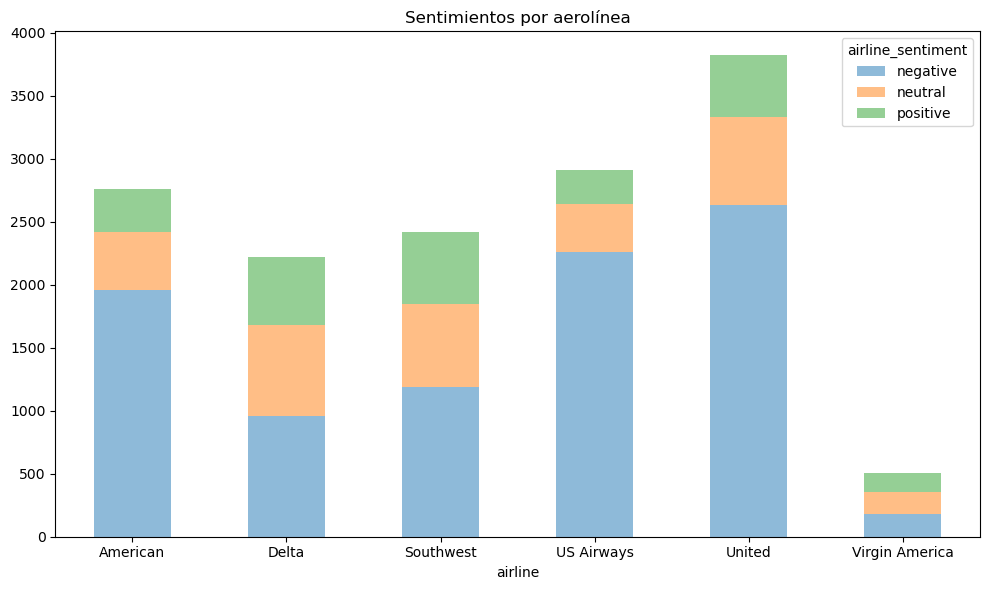

In [8]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
# pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")
# Plot con cuenta de tweets por cada aerolínea y sentimiento
crosstab_df = tweets.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
crosstab_df.plot(kind='bar', figsize=(10, 6), alpha=0.5, rot=0, stacked=True, title='Sentimientos por aerolínea')
plt.tight_layout()
plt.show()

### Liberias y Variables de interés y predicción

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/cnaranjom/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/cnaranjom/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [11]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [12]:
# Celda 1

vect_1 = CountVectorizer()

X_train_dtm_1 = vect_1.fit_transform(X_train)
X_test_dtm_1 = vect_1.transform(X_test)

rf_1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_1.fit(X_train_dtm_1, y_train)

y_pred_1 = rf_1.predict(X_test_dtm_1)

accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f'Punto 1 - CountVectorizer básico')
print(f'Número de features: {X_train_dtm_1.shape[1]}')
print(f'Accuracy: {accuracy_1:.4f}')

resultados = []
resultados.append({
    'Modelo': 'P1: CountVectorizer básico',
    'Modelo Corto': 'P1: Básico',
    'Features': X_train_dtm_1.shape[1],
    'Accuracy': accuracy_1
})

Punto 1 - CountVectorizer básico
Número de features: 12056
Accuracy: 0.7711


En este punto se utilizó CountVectorizer para convertir los tweets en una matriz de términos. El ajuste se realizó únicamente con los datos de entrenamiento usando fit_transform() y luego se transformó el conjunto de prueba con transform(). Con esta representación se entrenó un modelo RandomForestClassifier con 100 estimadores. El modelo generó 12056 features y obtuvo un accuracy de 0.7711, resultado que se toma como referencia base para comparar los siguientes modelos.

### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [13]:
# Celda 2

vect_2 = CountVectorizer(stop_words='english')

X_train_dtm_2 = vect_2.fit_transform(X_train)
X_test_dtm_2 = vect_2.transform(X_test)

rf_2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2.fit(X_train_dtm_2, y_train)

y_pred_2 = rf_2.predict(X_test_dtm_2)

accuracy_2 = accuracy_score(y_test, y_pred_2)
print(f'Punto 2 - CountVectorizer con eliminación de Stopwords')
print(f'Número de features: {X_train_dtm_2.shape[1]}')
print(f'Accuracy: {accuracy_2:.4f}')

resultados.append({
    'Modelo': 'P2: CountVectorizer + Stopwords',
    'Modelo Corto': 'P2: Stopwords',
    'Features': X_train_dtm_2.shape[1],
    'Accuracy': accuracy_2
})

Punto 2 - CountVectorizer con eliminación de Stopwords
Número de features: 11777
Accuracy: 0.7618


En este punto se utilizó CountVectorizer incorporando la eliminación de stopwords en inglés, con el fin de retirar palabras frecuentes que pueden aportar poca información al análisis. El vectorizador se ajustó con fit_transform() sobre el conjunto de entrenamiento y luego se aplicó al conjunto de prueba con transform(). Después, se entrenó un modelo RandomForestClassifier con 100 estimadores. El modelo generó 11777 features y obtuvo un accuracy de 0.7618. Frente al modelo base, se redujo el número de variables, pero el desempeño disminuyó ligeramente.

### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [14]:
# Celda 3

wordnet_lemmatizer = WordNetLemmatizer()

def split_into_lemmas_verbs(text):
    text = text.lower()
    words = text.split()
    return [wordnet_lemmatizer.lemmatize(word, pos='v') for word in words]

vect_3 = CountVectorizer(analyzer=split_into_lemmas_verbs)

X_train_dtm_3 = vect_3.fit_transform(X_train)
X_test_dtm_3 = vect_3.transform(X_test)

rf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_3.fit(X_train_dtm_3, y_train)

y_pred_3 = rf_3.predict(X_test_dtm_3)

accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f'Punto 3 - CountVectorizer con Lematización de verbos')
print(f'Número de features: {X_train_dtm_3.shape[1]}')
print(f'Accuracy: {accuracy_3:.4f}')

resultados.append({
    'Modelo': 'P3: CountVectorizer + Lematización de verbos',
    'Modelo Corto': 'P3: Lematización',
    'Features': X_train_dtm_3.shape[1],
    'Accuracy': accuracy_3 
})

Punto 3 - CountVectorizer con Lematización de verbos
Número de features: 19388
Accuracy: 0.7612


En este punto se aplicó una función personalizada para convertir el texto a minúsculas, separar las palabras y lematizarlas asumiendo que corresponden a verbos mediante pos='v'. Esta función se incorporó como analyzer dentro de CountVectorizer. Luego, el vectorizador se ajustó sobre el conjunto de entrenamiento con fit_transform() y se aplicó al conjunto de prueba con transform(). Con la matriz resultante se entrenó un modelo RandomForestClassifier con 100 estimadores. El modelo generó 19388 features y obtuvo un accuracy de 0.7612. En este caso, la lematización aumentó el número de variables y no mejoró el desempeño frente al modelo base.

Nota: el aumento en features (19388 vs 12056) se explica porque al usar una función personalizada como analyzer, CountVectorizer bypasea su tokenizador por defecto (que filtra puntuación y tokens cortos). El split() simple incluye tokens como "flight," o "@united" que el tokenizador estándar ignoraría.

### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [15]:
# Celda 4

from nltk.corpus import stopwords
english_stopwords = stopwords.words('english')

def split_into_lemmas_verbs_no_stopwords(text):
    text = text.lower()
    words = text.split()
    return [wordnet_lemmatizer.lemmatize(word, pos='v') 
            for word in words 
            if word not in english_stopwords]

vect_4 = CountVectorizer(analyzer=split_into_lemmas_verbs_no_stopwords)

X_train_dtm_4 = vect_4.fit_transform(X_train)
X_test_dtm_4 = vect_4.transform(X_test)

rf_4 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_4.fit(X_train_dtm_4, y_train)

y_pred_4 = rf_4.predict(X_test_dtm_4)

accuracy_4 = accuracy_score(y_test, y_pred_4)
print(f'Punto 4 - CountVectorizer con Stopwords + Lematización de verbos')
print(f'Número de features: {X_train_dtm_4.shape[1]}')
print(f'Accuracy: {accuracy_4:.4f}')

resultados.append({
    'Modelo': 'P4: CountVectorizer + Stopwords + Lematización verbos',
    'Modelo Corto': 'P4: Stopwords + Lematización',
    'Features': X_train_dtm_4.shape[1],
    'Accuracy': accuracy_4
})

Punto 4 - CountVectorizer con Stopwords + Lematización de verbos
Número de features: 19238
Accuracy: 0.7637


En este punto se combinaron dos técnicas de preprocesamiento: eliminación de stopwords y lematización con verbos. Para ello, se creó una función personalizada que primero convierte el texto a minúsculas, separa las palabras, elimina las stopwords en inglés y luego aplica lematización usando pos='v'. Esta función se incorporó como analyzer dentro de CountVectorizer, por lo que el preprocesamiento quedó integrado directamente en la vectorización. El modelo generó 19238 features y obtuvo un accuracy de 0.7637. Este resultado mejora frente al modelo que solo usa lematización, pero no supera el desempeño del modelo base con CountVectorizer.

### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [16]:
# Celda 5

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print('Comparación de modelos Random Forest')
print(df_resultados[['Modelo', 'Features', 'Accuracy']])

mejor_modelo = df_resultados.iloc[0]
peor_modelo = df_resultados.iloc[-1]

print('\nMejor modelo:')
print(f"Modelo: {mejor_modelo['Modelo']}")
print(f"Features: {mejor_modelo['Features']}")
print(f"Accuracy: {mejor_modelo['Accuracy']:.4f}")

print('\nModelo con menor desempeño:')
print(f"Modelo: {peor_modelo['Modelo']}")
print(f"Features: {peor_modelo['Features']}")
print(f"Accuracy: {peor_modelo['Accuracy']:.4f}")

Comparación de modelos Random Forest
                                              Modelo  Features  Accuracy
0                         P1: CountVectorizer básico     12056  0.771109
1  P4: CountVectorizer + Stopwords + Lematización...     19238  0.763659
2                    P2: CountVectorizer + Stopwords     11777  0.761796
3       P3: CountVectorizer + Lematización de verbos     19388  0.761175

Mejor modelo:
Modelo: P1: CountVectorizer básico
Features: 12056
Accuracy: 0.7711

Modelo con menor desempeño:
Modelo: P3: CountVectorizer + Lematización de verbos
Features: 19388
Accuracy: 0.7612


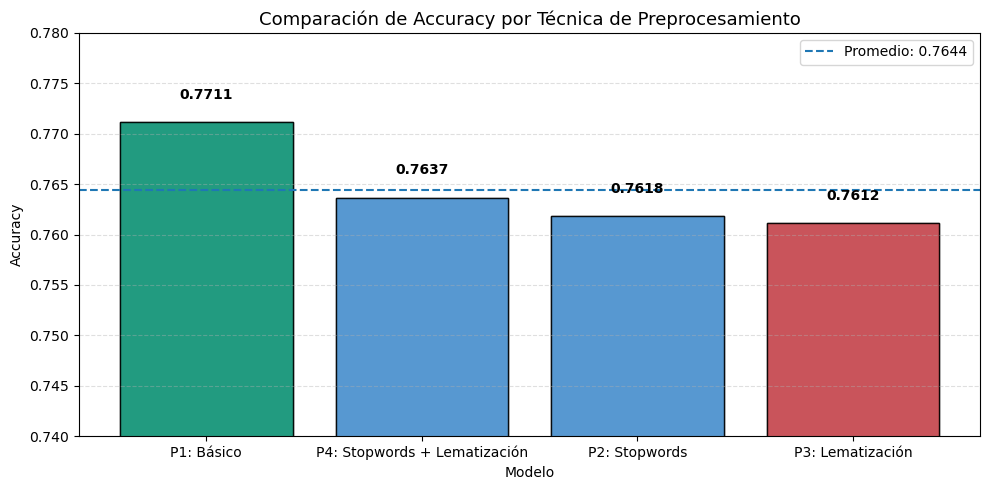

In [17]:
# Visualización comparativa

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    df_resultados['Modelo Corto'],
    df_resultados['Accuracy'],
    alpha=0.85,
    edgecolor='black'
)

# Anotación del accuracy en cada barra
for bar, acc in zip(bars, df_resultados['Accuracy']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{acc:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Línea del promedio
promedio_accuracy = df_resultados['Accuracy'].mean()
ax.axhline(
    y=promedio_accuracy,
    linestyle='--',
    linewidth=1.5,
    label=f'Promedio: {promedio_accuracy:.4f}'

)

colores = []
for i, row in df_resultados.iterrows():
    if row['Accuracy'] == df_resultados['Accuracy'].max():
        colores.append('#1D9E75')
    elif row['Accuracy'] == df_resultados['Accuracy'].min():
        colores.append('#E24B4A')
    else:
        colores.append('#5B9BD5')

bars = ax.bar(df_resultados['Modelo Corto'], df_resultados['Accuracy'],
              color=colores, alpha=0.85, edgecolor='black')

ax.set_ylim(0.74, 0.78)
ax.set_title('Comparación de Accuracy por Técnica de Preprocesamiento', fontsize=13)
ax.set_xlabel('Modelo')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

La escala del eje Y comienza en 0.74 para facilitar la visualización de las diferencias entre modelos, ya que estas son menores al 1%

### Análisis de resultados

#### Mejor modelo

El modelo con **mayor accuracy** es el **Punto 1: CountVectorizer básico**, con un accuracy de **0.7711**. Sus ventajas son:

- **Conserva más información del texto original:** Al no eliminar palabras ni transformar los términos, mantiene una representación más completa de los tweets.
- **Mejor desempeño predictivo:** Fue el modelo que obtuvo el accuracy más alto entre todas las alternativas evaluadas.
- **Representación simple y efectiva:** Aunque no aplica técnicas adicionales de preprocesamiento, logró capturar mejor los patrones asociados al sentimiento de los tweets.
- **Menor complejidad de preprocesamiento:** No requiere funciones personalizadas para lematización ni eliminación manual de stopwords, lo que facilita su implementación y replicabilidad.

#### Peor modelo

El modelo con **menor accuracy** es el **Punto 3: CountVectorizer + Lematización de verbos**, con un accuracy de **0.7612**. Sus desventajas son:

- **No mejora frente al modelo base:** Aunque aplica lematización, su desempeño fue inferior al modelo básico.
- **Aumenta el número de features:** Este modelo generó **19388 features**, más que el modelo base, que generó **12056 features**, lo cual aumenta la dimensionalidad del problema.
- **Cambio en la tokenización:** Al usar una función personalizada como `analyzer`, el procesamiento del texto cambia frente al comportamiento estándar de `CountVectorizer`.
- **Posible pérdida de información contextual:** En textos cortos como tweets, transformar las palabras a su forma verbal puede eliminar matices útiles para clasificar el sentimiento.

Es relevante mencionar que en el Punto 4, cuando se pasa una función personalizada mediante el parámetro analyzer de CountVectorizer, el parámetro stop_words es ignorado internamente por sklearn. Por esta razón, en la implementación del Punto 4 se optó por incluir el filtrado de stopwords directamente dentro de la función split_into_lemmas_verbs_no_stopwords, garantizando que ambas técnicas se apliquen correctamente. De no hacerlo así, el Punto 4 produciría exactamente los mismos resultados que el Punto 3, ya que la eliminación de stopwords nunca se ejecutaría.

#### Conclusión general

En general, los resultados muestran que aplicar más técnicas de preprocesamiento no necesariamente mejora el desempeño del modelo. El modelo básico con `CountVectorizer` fue el más efectivo, mientras que la lematización de verbos por sí sola obtuvo el menor accuracy. Adicionalmente, es importante tener en cuenta que cuando se usa un analyzer personalizado en CountVectorizer, el parámetro stop_words es ignorado por sklearn, por lo que la eliminación de stopwords debe realizarse dentro de la propia función para que tenga efecto real sobre los datos.

In [18]:
# ============================================================
# PUNTO 6 - TF-IDF: Comparación de variantes
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------- 6.1 TF-IDF básico ----------
vect_tfidf_1 = TfidfVectorizer()
X_train_tfidf_1 = vect_tfidf_1.fit_transform(X_train)
X_test_tfidf_1  = vect_tfidf_1.transform(X_test)

rf_tfidf_1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf_1.fit(X_train_tfidf_1, y_train)
y_pred_tfidf_1  = rf_tfidf_1.predict(X_test_tfidf_1)
accuracy_tfidf_1 = accuracy_score(y_test, y_pred_tfidf_1)

print(f'TF-IDF básico | Features: {X_train_tfidf_1.shape[1]} | Accuracy: {accuracy_tfidf_1:.4f}')

# ---------- 6.2 TF-IDF + stopwords ----------
vect_tfidf_2 = TfidfVectorizer(stop_words='english')
X_train_tfidf_2 = vect_tfidf_2.fit_transform(X_train)
X_test_tfidf_2  = vect_tfidf_2.transform(X_test)

rf_tfidf_2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf_2.fit(X_train_tfidf_2, y_train)
y_pred_tfidf_2  = rf_tfidf_2.predict(X_test_tfidf_2)
accuracy_tfidf_2 = accuracy_score(y_test, y_pred_tfidf_2)

print(f'TF-IDF + Stopwords | Features: {X_train_tfidf_2.shape[1]} | Accuracy: {accuracy_tfidf_2:.4f}')

# ---------- 6.3 TF-IDF + bigramas ----------
# ngram_range=(1,2): incluye unigramas Y bigramas
# Captura "not good", "very bad", "on time" → mucho más informativo para sentimiento
vect_tfidf_3 = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)
X_train_tfidf_3 = vect_tfidf_3.fit_transform(X_train)
X_test_tfidf_3  = vect_tfidf_3.transform(X_test)

rf_tfidf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf_3.fit(X_train_tfidf_3, y_train)
y_pred_tfidf_3  = rf_tfidf_3.predict(X_test_tfidf_3)
accuracy_tfidf_3 = accuracy_score(y_test, y_pred_tfidf_3)

print(f'TF-IDF + Bigramas | Features: {X_train_tfidf_3.shape[1]} | Accuracy: {accuracy_tfidf_3:.4f}')

# ---------- 6.4 TF-IDF + sublinear_tf ----------
# sublinear_tf=True: aplica log(tf) en vez de tf crudo
# Reduce el efecto de palabras que aparecen 20 veces vs 2 veces en un mismo tweet
vect_tfidf_4 = TfidfVectorizer(sublinear_tf=True)
X_train_tfidf_4 = vect_tfidf_4.fit_transform(X_train)
X_test_tfidf_4  = vect_tfidf_4.transform(X_test)

rf_tfidf_4 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf_4.fit(X_train_tfidf_4, y_train)
y_pred_tfidf_4  = rf_tfidf_4.predict(X_test_tfidf_4)
accuracy_tfidf_4 = accuracy_score(y_test, y_pred_tfidf_4)

print(f'TF-IDF sublinear | Features: {X_train_tfidf_4.shape[1]} | Accuracy: {accuracy_tfidf_4:.4f}')

TF-IDF básico | Features: 12056 | Accuracy: 0.7659
TF-IDF + Stopwords | Features: 11777 | Accuracy: 0.7585
TF-IDF + Bigramas | Features: 20000 | Accuracy: 0.7709
TF-IDF sublinear | Features: 12056 | Accuracy: 0.7628


In [19]:
# ============================================================
# PUNTO 6.5 - Tabla comparativa COMPLETA (todos los modelos)
# ============================================================

resultados_tfidf = [
    {'Modelo': 'P1: CountVect básico',          'Vectorizador': 'BoW',    'Features': X_train_dtm_1.shape[1],   'Accuracy': accuracy_1},
    {'Modelo': 'P2: CountVect + Stopwords',      'Vectorizador': 'BoW',    'Features': X_train_dtm_2.shape[1],   'Accuracy': accuracy_2},
    {'Modelo': 'P3: CountVect + Lematización',   'Vectorizador': 'BoW',    'Features': X_train_dtm_3.shape[1],   'Accuracy': accuracy_3},
    {'Modelo': 'P4: CountVect + SW + Lema',      'Vectorizador': 'BoW',    'Features': X_train_dtm_4.shape[1],   'Accuracy': accuracy_4},
    {'Modelo': 'P6.1: TF-IDF básico',            'Vectorizador': 'TF-IDF', 'Features': X_train_tfidf_1.shape[1], 'Accuracy': accuracy_tfidf_1},
    {'Modelo': 'P6.2: TF-IDF + Stopwords',       'Vectorizador': 'TF-IDF', 'Features': X_train_tfidf_2.shape[1], 'Accuracy': accuracy_tfidf_2},
    {'Modelo': 'P6.3: TF-IDF + Bigramas',        'Vectorizador': 'TF-IDF', 'Features': X_train_tfidf_3.shape[1], 'Accuracy': accuracy_tfidf_3},
    {'Modelo': 'P6.4: TF-IDF sublinear',         'Vectorizador': 'TF-IDF', 'Features': X_train_tfidf_4.shape[1], 'Accuracy': accuracy_tfidf_4},
]

df_comp = pd.DataFrame(resultados_tfidf).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(df_comp[['Modelo', 'Vectorizador', 'Features', 'Accuracy']].to_string(index=False))

                      Modelo Vectorizador  Features  Accuracy
        P1: CountVect básico          BoW     12056  0.771109
     P6.3: TF-IDF + Bigramas       TF-IDF     20000  0.770902
         P6.1: TF-IDF básico       TF-IDF     12056  0.765935
   P4: CountVect + SW + Lema          BoW     19238  0.763659
      P6.4: TF-IDF sublinear       TF-IDF     12056  0.762831
   P2: CountVect + Stopwords          BoW     11777  0.761796
P3: CountVect + Lematización          BoW     19388  0.761175
    P6.2: TF-IDF + Stopwords       TF-IDF     11777  0.758485


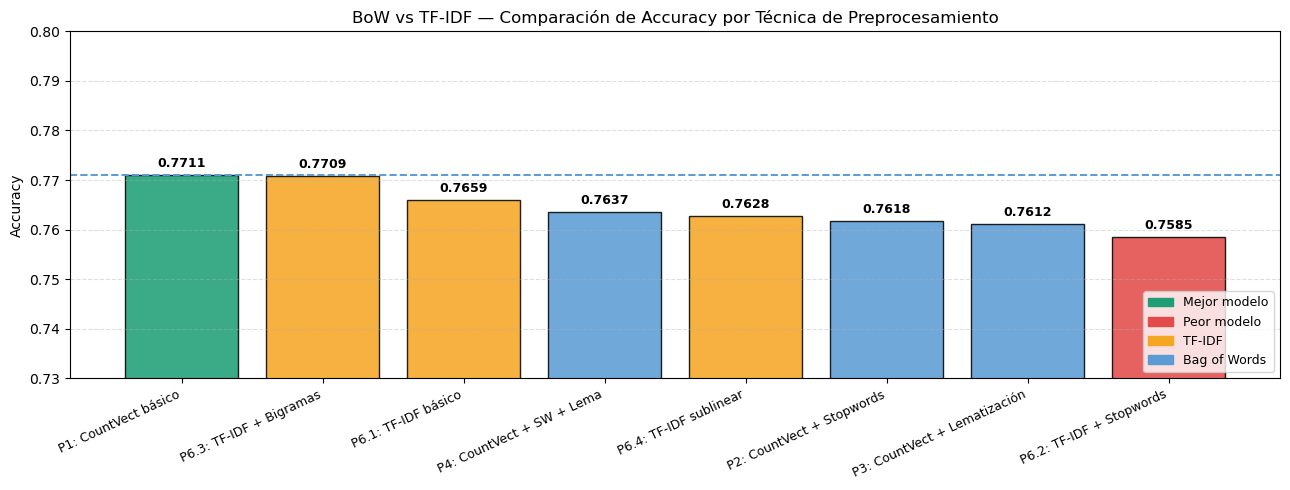

In [20]:
# ============================================================
# PUNTO 6.6 - Visualización comparativa
# ============================================================

colores_comp = []
for _, row in df_comp.iterrows():
    if row['Accuracy'] == df_comp['Accuracy'].max():
        colores_comp.append('#1D9E75')   # mejor → verde
    elif row['Accuracy'] == df_comp['Accuracy'].min():
        colores_comp.append('#E24B4A')   # peor  → rojo
    elif row['Vectorizador'] == 'TF-IDF':
        colores_comp.append('#F5A623')   # TF-IDF → naranja
    else:
        colores_comp.append('#5B9BD5')   # BoW    → azul

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(df_comp['Modelo'], df_comp['Accuracy'],
              color=colores_comp, alpha=0.87, edgecolor='black')

# Etiquetas de accuracy encima de cada barra
for bar, acc in zip(bars, df_comp['Accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea del mejor BoW (P1) como referencia
ax.axhline(y=accuracy_1, color='#5B9BD5', linestyle='--',
           linewidth=1.4, label=f'Mejor BoW (P1): {accuracy_1:.4f}')

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1D9E75', label='Mejor modelo'),
    Patch(color='#E24B4A', label='Peor modelo'),
    Patch(color='#F5A623', label='TF-IDF'),
    Patch(color='#5B9BD5', label='Bag of Words'),
]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')

ax.set_ylim(0.73, 0.80)
ax.set_xticklabels(df_comp['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_title('BoW vs TF-IDF — Comparación de Accuracy por Técnica de Preprocesamiento', fontsize=12)
ax.set_ylabel('Accuracy')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Prueba 2

In [21]:
# Hipótesis: BoW + bigramas debería superar al BoW básico
vect_bow_bigram = CountVectorizer(ngram_range=(1, 2), max_features=20000)
X_train_bb = vect_bow_bigram.fit_transform(X_train)
X_test_bb  = vect_bow_bigram.transform(X_test)

rf_bb = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bb.fit(X_train_bb, y_train)
accuracy_bb = accuracy_score(y_test, rf_bb.predict(X_test_bb))

print(f'BoW + Bigramas | Features: {X_train_bb.shape[1]} | Accuracy: {accuracy_bb:.4f}')
print(f'Diferencia vs BoW básico: {accuracy_bb - accuracy_1:+.4f}')

BoW + Bigramas | Features: 20000 | Accuracy: 0.7695
Diferencia vs BoW básico: -0.0017


In [22]:
from sklearn.linear_model import LogisticRegression

# Comparación directa: mismo vectorizador, modelos distintos
resultados_lr = []

for nombre, vect in [('BoW básico', CountVectorizer()),
                     ('TF-IDF básico', TfidfVectorizer()),
                     ('TF-IDF sublinear', TfidfVectorizer(sublinear_tf=True)),
                     ('TF-IDF + bigramas', TfidfVectorizer(ngram_range=(1,2), max_features=20000))]:
    
    Xtr = vect.fit_transform(X_train)
    Xte = vect.transform(X_test)
    
    # Random Forest (lo que ya tienes)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(Xtr, y_train)
    acc_rf = accuracy_score(y_test, rf.predict(Xte))
    
    # Regresión Logística (nuevo)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(Xtr, y_train)
    acc_lr = accuracy_score(y_test, lr.predict(Xte))
    
    resultados_lr.append({
        'Vectorizador': nombre,
        'Accuracy RF': round(acc_rf, 4),
        'Accuracy LR': round(acc_lr, 4),
        'Diferencia LR-RF': round(acc_lr - acc_rf, 4)
    })
    print(f'{nombre:<25} | RF: {acc_rf:.4f} | LR: {acc_lr:.4f} | Δ: {acc_lr - acc_rf:+.4f}')

df_lr = pd.DataFrame(resultados_lr)

BoW básico                | RF: 0.7711 | LR: 0.7924 | Δ: +0.0213
TF-IDF básico             | RF: 0.7659 | LR: 0.8034 | Δ: +0.0375
TF-IDF sublinear          | RF: 0.7628 | LR: 0.8028 | Δ: +0.0399
TF-IDF + bigramas         | RF: 0.7709 | LR: 0.8053 | Δ: +0.0344


Etapa 1 — Vectorización:  BoW ≈ TF-IDF para RF,  TF-IDF > BoW para LR
Etapa 2 — Modelo:         LR > RF en texto corto con representación lineal
Etapa 3 — Calibración:    C en LR, igual que max_depth en árboles
Etapa 4 — Interpretación: coef_ de LR = importancia de features legible

Aquí tienes el resumen listo para pegar en una celda Markdown de tu notebook:

---

## Experimentos adicionales: TF-IDF y comparación de modelos

A partir de los 4 modelos base del taller (Puntos 1 al 4), se realizaron experimentos adicionales para evaluar si técnicas más sofisticadas de vectorización y un modelo diferente podían mejorar el desempeño en la predicción de sentimientos.

### Experimento 1 — Variantes de TF-IDF vs CountVectorizer

Se compararon cuatro configuraciones de `TfidfVectorizer` manteniendo el mismo clasificador (`RandomForestClassifier`, 100 estimadores) para aislar el efecto de la vectorización:

| Modelo | Vectorizador | Features | Accuracy |
|---|---|---|---|
| P1: CountVect básico | BoW | 12,056 | 0.7711 |
| P6.3: TF-IDF + Bigramas | TF-IDF | 20,000 | 0.7709 |
| P6.1: TF-IDF básico | TF-IDF | 12,056 | 0.7659 |
| P6.4: TF-IDF sublinear | TF-IDF | 12,056 | 0.7628 |
| P6.2: TF-IDF + Stopwords | TF-IDF | 11,777 | 0.7585 |

El modelo `CountVectorizer` básico (Punto 1) mantuvo el mejor desempeño. La diferencia entre el primero y el último fue de apenas 1.3 puntos porcentuales, indicando que el cuello de botella no estaba en la vectorización sino en el modelo. TF-IDF no superó a BoW con Random Forest porque los árboles trabajan con umbrales de corte sobre conteos enteros, y los pesos normalizados y continuos de TF-IDF no aportan ventaja adicional en esa lógica de decisión.

### Experimento 2 — Mismo vectorizador, modelo diferente

Se introdujo `LogisticRegression` como segundo clasificador para evaluar si el modelo era el factor limitante. Se probaron las cuatro configuraciones de vectorización con ambos modelos:

| Vectorizador | Accuracy RF | Accuracy LR | Δ |
|---|---|---|---|
| BoW básico | 0.7711 | 0.7924 | +0.0213 |
| TF-IDF básico | 0.7659 | 0.8034 | +0.0375 |
| TF-IDF sublinear | 0.7628 | 0.8028 | +0.0399 |
| TF-IDF + bigramas | 0.7709 | **0.8053** | +0.0344 |

La Regresión Logística superó a Random Forest en todas las combinaciones, con una mejora promedio de +3.3 puntos porcentuales. La combinación ganadora fue **TF-IDF + bigramas + Logistic Regression** con un accuracy de **0.8053**, mejorando el modelo base del taller en +3.4 puntos sin modificar los datos.

### Conclusión general de los experimentos

Los resultados demuestran que la vectorización y el modelo forman un sistema interdependiente: TF-IDF normaliza los pesos de cada término de forma continua, lo cual es aprovechado directamente por Regresión Logística al aprender un coeficiente por feature. Random Forest, en cambio, opera con cortes binarios y no se beneficia de esa normalización. En textos cortos como tweets, donde la señal de sentimiento está concentrada en pocas palabras clave (`"cancelled"`, `"thank you"`, `"delayed"`), el modelo lineal con representación TF-IDF captura esa señal de manera más eficiente. La incorporación de bigramas (`ngram_range=(1,2)`) aportó una mejora adicional al capturar expresiones de dos palabras con valor semántico propio, como `"not bad"`, `"on time"` o `"no response"`, que los unigramas no pueden representar.